In [1]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


Patients per cluster:
Cluster_Label
2    39457
1    39111
0    18729
Name: count, dtype: int64


,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
Cluster_Label,,,,,,,,,,,,,,,,,,,,,
0,50.891719,2.001442,252.494420,6.027134,6.996738,5.998617,0.213946,0.252816,0.079769,24.766763,...,185.112553,54.581611,101.608949,117.416146,107.395590,155.066207,8.556906,6.363509,24.937738,0.514977
1,61.236532,1.999847,87.258725,5.825584,6.993281,5.974306,0.219861,0.304978,0.106364,27.632060,...,195.796451,52.865869,113.262612,131.435197,114.976068,165.200762,10.212630,6.684514,35.680806,0.686789
2,38.913906,2.010670,86.956484,6.148204,7.002557,6.018803,0.222166,0.196416,0.051677,24.018488,...,176.671820,54.955471,93.488430,113.507565,109.070026,157.222141,8.165135,6.432044,27.319403,0.554426


Sample shape: (1000, 3)
SHAP class count: 3
SHAP shape class 0: (1000, 3)
Plotting class 0


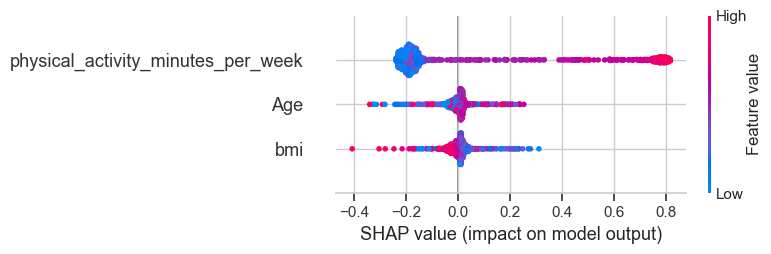

Plotting class 1


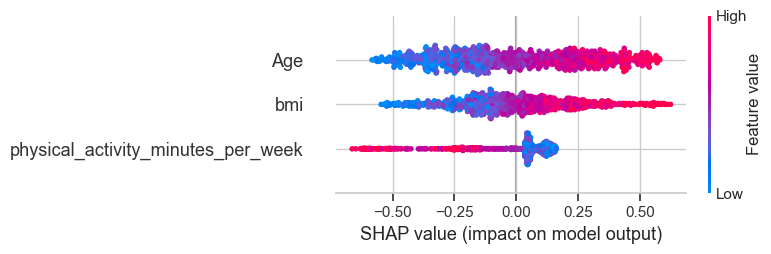

Plotting class 2


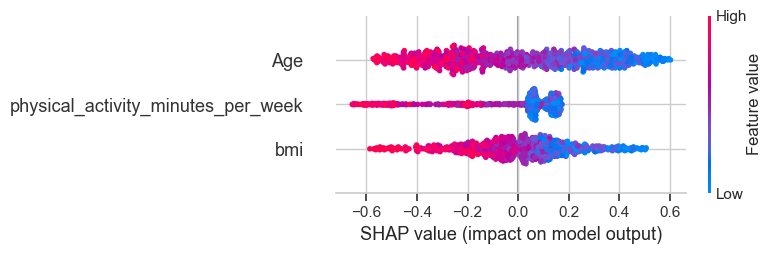

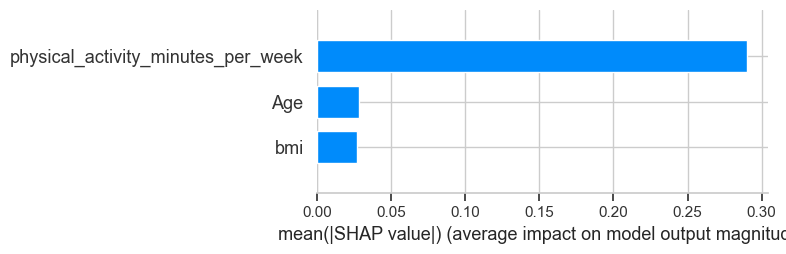

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")


df = pd.read_csv('Diabetes_and_LifeStyle_Dataset_.csv')


clustering_data = df[['bmi', 'Age', 'physical_activity_minutes_per_week']]


scaler = StandardScaler() 

scaled_features = scaler.fit_transform(clustering_data)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=clustering_data.columns
)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)


cluster_labels = kmeans.fit_predict(scaled_df)
df['Cluster_Label'] = cluster_labels


print("Patients per cluster:")
print(df['Cluster_Label'].value_counts())


cluster_profiles = df.groupby('Cluster_Label').mean(numeric_only=True)
display(cluster_profiles)


if 'BMI' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Cluster_Label', y='BMI', data=df, palette='viridis')
    plt.title('Distribution of BMI Across Patient Segments')
    plt.show()

sample_df = scaled_df.sample(n=1000, random_state=42)

model_cluster = RandomForestClassifier(
    random_state=42,
    n_estimators=50,
    max_depth=10
)

model_cluster.fit(scaled_df, cluster_labels)

explainer = shap.TreeExplainer(model_cluster)
shap_values = explainer.shap_values(sample_df)

if isinstance(shap_values, list):
    shap_values_list = shap_values
else:
    shap_values_list = [
        shap_values[:, :, i] for i in range(shap_values.shape[2])
    ]

print("Sample shape:", sample_df.shape)
print("SHAP class count:", len(shap_values_list))
print("SHAP shape class 0:", shap_values_list[0].shape)

for i in range(len(shap_values_list)):
    print(f"Plotting class {i}")
    shap.summary_plot(shap_values_list[i], sample_df)
    plt.show()

shap.summary_plot(shap_values_list[0], sample_df, plot_type="bar")
plt.show()

In [3]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(kmeans, "../artifacts/kmeans_model.pkl")
joblib.dump(scaler, "../artifacts/kmeans_scaler.pkl")

print("Saved successfully!")

Saved successfully!
